# Automatic Consumer Complaint Product Classification
## **An End-to-End NLP Pipeline for Financial Complaint Routing**

### - **Module:** M508 Big Data Analytics    
### - **Name:** Rakesh Goud Gajjela                                 
### - **GH Number:** GH1052130                                    
                             


## 1. Problem Statement

### Business Context
Every year, banks, lenders, and credit agencies receive an 
enormous number of complaints from customers about things like billing errors, unfair 
debt collection, or problems with their credit reports. Right now, someone at the 
company has to actually read each complaint and figure out which department it belongs 
to before anyone can act on it. When you're dealing with hundreds of thousands of 
complaints a year, that's a huge bottleneck - it's slow, it depends on whoever happens 
to be reading it that day, and it just doesn't scale.

### Why This Matters
If a company could automatically sort incoming complaints into the 
right category the moment they come in, customers would get help faster, the company 
would spend less time and money on manual sorting, and management would be able to spot 
patterns early - for example, if complaints about a particular loan product suddenly 
spike, that's something worth catching quickly rather than weeks later.

### Project Objective

The objective of this project is to develop and evaluate an NLP-based classification system that can automatically assign consumer financial complaints to the appropriate product category. The project compares a TF-IDF-based approach with SBERT embeddings and evaluates their performance using validation and test data. The aim is to identify a practical approach that could support faster and more consistent complaint routing while recognising the limitations of automated classification.

### Data Collection
For this project I'm using the CFPB Consumer Complaint Database, which 
contains real complaints submitted by consumers about financial products, along with 
the product category each complaint was labelled with (Consumer Financial Protection Bureau, n.d.).                   
Source: https://www.kaggle.com/datasets/selener/consumer-complaint-database 

For a real-world complaint-routing system, similar complaint narratives could be collected continuously from sources such as online complaint forms, customer service channels, or other internal complaint-management systems. The public CFPB dataset is used in this project as a representative historical dataset for developing and evaluating the NLP classification pipeline.


### NLP Task Formulation
This becomes a multiclass text classification task - given 
the text a customer wrote describing their complaint, the goal is to predict which 
product category (e.g. "Credit reporting," "Mortgage," "Student loan") it belongs to.

The predicted product category acts as a routing proxy, allowing a complaint to be directed to the appropriate internal team or department for further handling.

## 2. High-Level System Design

Before diving into code, it helps to step back and think about the big picture of what 
this system actually needs to do. Broadly, it's made up of five main pieces that feed 
into each other.

- **Data ingestion.** The first step is just getting the raw complaint records loaded and 
picking out the fields that actually matter for this task - mainly the complaint 
narrative and the product label it was tagged with. Everything else can be set aside 
for now.

- **Preprocessing.** Raw text is messy. Customers write in all sorts of styles - different 
capitalisation, punctuation, typos, filler words. Before a model can make sense of any 
of it, the text needs to be cleaned and normalised so the important signal isn't 
drowned out by noise.

- **Feature representation.** Machine learning models don't understand words the way we 
do - they need numbers. So once the text is cleaned, it has to be converted into some 
kind of numerical representation. This project uses TF-IDF, which captures how 
important a word is to a specific complaint relative to the training corpus.

- **Classification model.** This is the core of the system - a supervised model trained 
to look at the numerical representation of a complaint and predict which product 
category it most likely belongs to.

- **Evaluation.** Finally, before trusting this system to actually route complaints, it 
needs to be tested properly. Since the product categories aren't evenly distributed 
(some show up far more often than others), it's important to look beyond plain accuracy 
and use metrics like macro-F1 and a confusion matrix to see where the model is actually 
getting things wrong.

Each of these steps depends on the one before it - you can't extract features from text 
that hasn't been cleaned, and you can't trust a model's predictions without evaluating 
them properly. That's why all five pieces are necessary, not just nice-to-haves.

In a real-world implementation, the pipeline would continue beyond evaluation with **deployment and monitoring**. The trained model could be integrated into a complaint-routing system to support automatic categorisation, while monitoring would track model performance and changes in complaint patterns over time. These components are discussed further in the business recommendations section.

## 3. Data Loading and Exploration

In [1]:
import pandas as pd
df = pd.read_csv("rows.csv", low_memory=False)
df.head(3)


,Date received,Product,Sub-product,Issue,Sub-issue,Consumer complaint narrative,Company public response,Company,State,ZIP code,Tags,Consumer consent provided?,Submitted via,Date sent to company,Company response to consumer,Timely response?,Consumer disputed?,Complaint ID
0,05/10/2019,Checking or savings account,Checking account,Managing an account,Problem using a debit or ATM card,NaN,NaN,NAVY FEDERAL CREDIT UNION,FL,328XX,Older American,NaN,Web,05/10/2019,In progress,Yes,NaN,3238275
1,05/10/2019,Checking or savings account,Other banking product or service,Managing an account,Deposits and withdrawals,NaN,NaN,BOEING EMPLOYEES CREDIT UNION,WA,98204,NaN,NaN,Referral,05/10/2019,Closed with explanation,Yes,NaN,3238228
2,05/10/2019,Debt collection,Payday loan debt,Communication tactics,Frequent or repeated calls,NaN,NaN,CURO Intermediate Holdings,TX,751XX,NaN,NaN,Web,05/10/2019,Closed with explanation,Yes,NaN,3237964


In [2]:
print("Shape:", df.shape)
print()
print("Columns:", df.columns.tolist())
print()
print("Missing values per column:")
print(df.isna().sum())
print()
print("Number of unique product categories:", df['Product'].nunique())
print()
print("Product value counts:")
print(df['Product'].value_counts())

Shape: (1282355, 18)

Columns: ['Date received', 'Product', 'Sub-product', 'Issue', 'Sub-issue', 'Consumer complaint narrative', 'Company public response', 'Company', 'State', 'ZIP code', 'Tags', 'Consumer consent provided?', 'Submitted via', 'Date sent to company', 'Company response to consumer', 'Timely response?', 'Consumer disputed?', 'Complaint ID']

Missing values per column:
Date received                         0
Product                               0
Sub-product                      235166
Issue                                 0
Sub-issue                        531186
Consumer complaint narrative     898791
Company public response          833273
Company                               0
State                             19400
ZIP code                         115298
Tags                            1106712
Consumer consent provided?       591701
Submitted via                         0
Date sent to company                  0
Company response to consumer          7
Timely response

Looking at the data, a few things immediately stand out.

**Narrative coverage.** Out of about 1.28 million complaints, roughly 900,000 are missing the actual narrative text - meaning only around 380,000 complaints (about 30%) have the free-text description we actually need for this task. This isn't a data quality issue exactly; consumer narratives are published only when the consumer provides consent, so many complaints do not have publicly available narrative text (Consumer Financial Protection Bureau, n.d.). Since our whole task depends on that text field, we'll be working with this smaller subset going forward.

**Category duplication.** There are 18 raw product categories, but several of them are clearly the same thing labelled differently. This dataset spans complaints from 2011 to 2019, and the CFPB changed its official product taxonomy partway through that period - so older complaints use one naming scheme and newer ones use another (Consumer Financial Protection Bureau, n.d.). For example, "Credit reporting" and "Credit reporting, credit repair services, or other personal consumer reports" ...

**Category Consolidation.** The original dataset contains product labels that reflect changes in the CFPB product taxonomy over time. Categories referring to the same or closely related financial products were consolidated to reduce artificial distinctions caused by changes in historical labelling. This makes the classification task more consistent across the dataset and reduces unnecessary class fragmentation (Consumer Financial Protection Bureau, n.d.).

The trade-off is that some finer-grained product distinctions are lost. However, the resulting nine categories provide a more consistent target for the NLP classification task.

**Class imbalance.** The categories are heavily imbalanced even before merging - 
Mortgage alone has over 278,000 complaints, while Virtual currency has just 18. This 
confirms that plain accuracy won't be a reliable evaluation metric later on; we'll need 
macro-F1 and a confusion matrix to see how the model performs on the smaller categories, 
not just the dominant ones.

In [3]:
category_map = {
    "Credit reporting, credit repair services, or other personal consumer reports": "Credit reporting",
    "Credit reporting": "Credit reporting",

    "Mortgage": "Mortgage",

    "Debt collection": "Debt collection",

    "Credit card": "Credit card or prepaid card",
    "Credit card or prepaid card": "Credit card or prepaid card",
    "Prepaid card": "Credit card or prepaid card",

    "Bank account or service": "Checking or savings account",
    "Checking or savings account": "Checking or savings account",

    "Consumer Loan": "Consumer loan",
    "Vehicle loan or lease": "Consumer loan",
    "Payday loan, title loan, or personal loan": "Consumer loan",
    "Payday loan": "Consumer loan",

    "Student loan": "Student loan",

    "Money transfer, virtual currency, or money service": "Money transfer or virtual currency",
    "Money transfers": "Money transfer or virtual currency",
    "Virtual currency": "Money transfer or virtual currency",

    "Other financial service": "Other financial service",
}

df['Product_clean'] = df['Product'].map(category_map)
print("Unmapped rows:", df['Product_clean'].isna().sum())
print()
print("New category counts:")
print(df['Product_clean'].value_counts())

Unmapped rows: 0

New category counts:
Product_clean
Credit reporting                      366410
Mortgage                              278098
Debt collection                       244873
Credit card or prepaid card           140662
Checking or savings account           126847
Consumer loan                          57185
Student loan                           51685
Money transfer or virtual currency     15536
Other financial service                 1059
Name: count, dtype: int64


After merging near-duplicate categories, we're left with 9 clean product classes, and 
the imbalance is still very visible: Credit reporting alone makes up over 366,000 
complaints, while Other financial service has just over 1,000. This is a roughly 
350-to-1 ratio between the largest and smallest class, and it's a realistic reflection 
of the real world - some financial products simply generate far more complaints than 
others. 

This confirms two things we'll need to carry forward: first, when we build the training 
set, we should be careful that smaller classes aren't accidentally left out or 
under-represented; second, when we evaluate the model later, macro-F1 (which treats 
every class equally regardless of size) will tell a very different - and more honest - 
story than plain accuracy.

Next, we filter down to only the complaints that actually have a narrative, since that's 
the text our model will learn from.

In [4]:
df_text = df[df['Consumer complaint narrative'].notna()].copy()
df_text = df_text[df_text['Consumer complaint narrative'].str.strip() != ""]

print("Rows with narrative:", df_text.shape)
print()
print("Class distribution after filtering to narratives only:")
print(df_text['Product_clean'].value_counts())
print()
print("Sample narrative:")
print(df_text['Consumer complaint narrative'].iloc[0])
print()
print("Narrative length stats (in characters):")
print(df_text['Consumer complaint narrative'].str.len().describe())

Rows with narrative: (383564, 19)

Class distribution after filtering to narratives only:
Product_clean
Credit reporting                      123966
Debt collection                        86710
Mortgage                               52987
Credit card or prepaid card            41667
Checking or savings account            27766
Student loan                           21810
Consumer loan                          21387
Money transfer or virtual currency      6979
Other financial service                  292
Name: count, dtype: int64

Sample narrative:
The Summer of XX/XX/2018 I was denied a mortgage loan due to a charge off from XXXX XXXX credit card. I both mailed an account validation letter and disputed this debt with the credit bureaus and the credit card company several times. Only the credit bureaus responded that this debt was verified but showed no proof as I requested. XXXX XXXX still has not responded to any of my letters since XX/XX/2018. All I asked was that the credit bureaus 

Filtering to narratives leaves 383,564 complaints - the imbalance persists in roughly 
the same proportions (Credit reporting still largest, Other financial service still 
smallest, now about 424:1). 

Because complaints without narratives cannot be used for text classification, the analysis is restricted to the 383,564 complaints that contain narrative text. This restriction may affect how representative the final sample is of the full complaint dataset and is therefore considered a limitation of the analysis.

Two things stand out in the sample text that we'll need to handle during preprocessing:
first, personal details (dates, names) are redacted with placeholders like "XX/XX/2018" 
and "XXXX XXXX" - these aren't useful signal and should likely be cleaned or removed. 
Second, narrative length varies enormously (from 5 to over 31,000 characters, median 
744), so we may want to consider this when choosing a max feature/sequence length later.

Given the size of the full narrative subset (383,564 rows), we take a sample of about 20,000 complaints to keep training and evaluation computationally manageable. The sampling remains stratified across the main product categories so that their original distribution is broadly preserved.

Because "Other financial service" is a very small category, proportional sampling would leave too few examples for reliable training and evaluation. Therefore, all available narrative records from this category are retained, while the remaining sample is drawn proportionally from the other categories. This slightly changes the original class proportions but provides a more reliable representation of the minority class.

This approach allows the model to retain all nine product categories while still keeping the dataset small enough for efficient experimentation. However, because the minority class is intentionally oversampled relative to its original proportion, the final sample should not be interpreted as fully representative of the original complaint population.

In [5]:
SAMPLE_SIZE = 20000
minority_class = "Other financial service"

df_minority = df_text[df_text['Product_clean'] == minority_class]
df_other = df_text[df_text['Product_clean'] != minority_class]

remaining_size = SAMPLE_SIZE - len(df_minority)

df_sample_other = (
    df_other.groupby('Product_clean', group_keys=False)[df_other.columns]
    .apply(lambda x: x.sample(
        n=round(len(x) / len(df_other) * remaining_size),
        random_state=42
    ))
)

df_sample = pd.concat([df_sample_other, df_minority], ignore_index=True)
if len(df_sample) > SAMPLE_SIZE:
    df_sample = df_sample.sample(n=SAMPLE_SIZE, random_state=42)

print("Sample shape:", df_sample.shape)
print()
print(df_sample['Product_clean'].value_counts())

Sample shape: (20000, 19)

Product_clean
Credit reporting                      6374
Debt collection                       4459
Mortgage                              2725
Credit card or prepaid card           2143
Checking or savings account           1428
Student loan                          1121
Consumer loan                         1100
Money transfer or virtual currency     358
Other financial service                292
Name: count, dtype: int64


The final sample retains all nine product categories while providing a more useful number of examples for the minority class. In particular, all 292 available narrative records from the "Other financial service" category are retained so that this class can be included meaningfully in model training and evaluation.

## 4. Preprocessing

Before the text can be turned into features, it needs cleaning. The complaint narratives contain redacted placeholders (such as "XX/XX/2018" and "XXXX"), inconsistent casing, and punctuation that may add noise. We apply lowercasing, removal of redaction placeholders, removal of punctuation and numbers, tokenization, and selective stopword removal.

Stopword removal is applied carefully because some common words can carry important meaning in complaint narratives. In particular, negation words such as "not", "no", and "never" are retained because removing them could change the meaning of statements such as "not mine" or "no proof of debt". Stemming and lemmatization are not applied because the TF-IDF model can work directly with the cleaned word forms and additional normalization is not necessary for this baseline.

In [6]:
import re
import nltk
from nltk.corpus import stopwords

nltk.download('stopwords', quiet=True)
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = text.lower()
    text = re.sub(r'\bxx+\S*', ' ', text)
    text = re.sub(r'[^a-z\s]', ' ', text)
    
    tokens = text.split()
    
    negation_words = {'no', 'not', 'nor', 'never', 'neither', 'without'}
    tokens = [t for t in tokens 
              if (t not in stop_words or t in negation_words) and len(t) > 1]
    
    return ' '.join(tokens)

df_sample['clean_narrative'] = df_sample['Consumer complaint narrative'].apply(clean_text)

print("BEFORE:")
print(df_sample['Consumer complaint narrative'].iloc[0])

print("\nAFTER:")
print(df_sample['clean_narrative'].iloc[0])

BEFORE:
My credit report has been ok until Just Recently With information not belonging me XXXX- ( Auto ) {$1300.00} XXXX XXXX ( other ) No proof of debt INCORRECT ADDRESS : XXXX XXXX XXXX XXXX XXXX, XXXX, Not Mine {$720.00} XXXX XXXX XXXX XXXX, XXXX Not Mine XXXX XXXX XXXX XXXX XXXX Other ) {$46.00} XXXX XXXX XXXX XXXX ( Auto ) {$200.00} XXXX XXXX XXXX XXXX XXXX XXXX XXXX XXXX, XXXX {$190.00} - XXXX, XXXX {$72.00} XXXX {$3900.00} I am therefore requestingNOT MINE, No proof of debt validation of a debts I do not owe AND basic inaccuracies on my credit report with Immediate effect now, EQUIFAX has not only been evasive over my report, they have never once provided the requested and official documentation required by law, nor have they corrected or prevent this wrong information the information, Not once have they provided me valid proof that it was mine NOR that I had a contract with either of this company, nor have they corrected the information. Pursuant to the Fair Debt Collection Pr

The cleaning worked as intended: redaction placeholders, punctuation, and common 
stopwords are gone, while the meaningful content (the actual complaint details) 
remains readable. This cleaned narrative is what we'll use for feature extraction.

The preprocessing also removes numbers and non-alphabetic characters to reduce noise and simplify the text representation. Although financial complaints may contain numerical information such as amounts and dates, the objective of this project is to classify complaints by product category rather than extract numerical information. Therefore, the experiment focuses on the textual information that is most directly related to the product being complained about. This is a trade-off because some potentially useful numerical information is removed.

## 5. Feature Representation

Since machine learning models need numbers, not raw text, we convert the cleaned 
narratives into a numerical representation using TF-IDF. TF-IDF weighs words by how 
important they are to a specific complaint relative to the training corpus - common 
words across all complaints get down-weighted, while distinctive words specific to a 
complaint get more weight. We cap the vocabulary size to keep the feature space 
manageable given our sample size.

We use bigrams in addition to single words (ngram_range=(1,2)) because short 
two-word phrases (e.g. "identity theft", "debt collector") often carry more 
specific meaning than individual words alone, and we cap the vocabulary at 5,000 
features to balance capturing useful terms against overfitting on a relatively 
small training sample.

In [7]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

X = df_sample['clean_narrative']
y = df_sample['Product_clean']

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))

X_train_tfidf = vectorizer.fit_transform(X_train)
X_val_tfidf = vectorizer.transform(X_val)
X_test_tfidf = vectorizer.transform(X_test)

print("Train shape:", X_train_tfidf.shape)
print("Validation shape:", X_val_tfidf.shape)
print("Test shape:", X_test_tfidf.shape)

print()
print("Train class counts:")
print(y_train.value_counts())

print()
print("Validation class counts:")
print(y_val.value_counts())

print()
print("Test class counts:")
print(y_test.value_counts())

Train shape: (14000, 5000)
Validation shape: (3000, 5000)
Test shape: (3000, 5000)

Train class counts:
Product_clean
Credit reporting                      4462
Debt collection                       3121
Mortgage                              1907
Credit card or prepaid card           1500
Checking or savings account           1000
Student loan                           785
Consumer loan                          770
Money transfer or virtual currency     251
Other financial service                204
Name: count, dtype: int64

Validation class counts:
Product_clean
Credit reporting                      956
Debt collection                       669
Mortgage                              409
Credit card or prepaid card           321
Checking or savings account           214
Student loan                          168
Consumer loan                         165
Money transfer or virtual currency     54
Other financial service                44
Name: count, dtype: int64

Test class counts:
Produ

The dataset is divided into three stratified subsets: 70% for training, 15% for validation, and 15% for final testing. The training set is used to fit the models, the validation set is used to compare modelling approaches, and the test set is kept separate for the final evaluation.

Stratification is used so that the nine product categories are represented across all three subsets. This is particularly important because the dataset remains imbalanced. The sampling strategy used earlier also retained all available examples from the small "Other financial service" category, providing a more meaningful number of examples for training and evaluation.

The TF-IDF vectorizer is fitted only on the training data during model comparison and is then used to transform the validation and test sets. This prevents information from the validation or test data from influencing the learned vocabulary and IDF weights. For the final model, the vectorizer is fitted on the combined training and validation data only after model selection, while the test set remains completely unseen until final evaluation. This helps prevent data leakage and provides a fairer estimate of model performance.

### TF-IDF Configuration

The TF-IDF representation is limited to the **5,000 most informative features** to control the dimensionality of the text representation and reduce computational cost. Both **unigrams and bigrams** are included using `ngram_range=(1, 2)`. Unigrams capture individual terms, while bigrams can capture short phrases that may be useful for distinguishing financial complaint categories, such as "credit report" or "debt collection". This configuration provides a balance between capturing useful textual information and keeping the model computationally manageable (Pedregosa et al., 2011).

## 6. Modeling

For the classification model, we start with a baseline: Logistic Regression on top of 
the TF-IDF features. Logistic Regression is a sensible starting point for text 
classification - it's fast to train, interpretable, and performs well on 
high-dimensional sparse features like TF-IDF. We use class_weight='balanced' to help 
the model pay more attention to smaller categories rather than being dominated by the 
largest ones.

We chose Logistic Regression over alternatives like Naive Bayes or SVM because it tends to perform reliably on sparse high-dimensional TF-IDF features and trains quickly enough to iterate on other design choices such as sampling and vectorizer settings. Logistic Regression also provides prediction probabilities that could potentially support a confidence-based routing workflow, although probability calibration would need to be evaluated separately before using a confidence threshold in a real-world system.

In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report

clf = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    random_state=42
)

clf.fit(X_train_tfidf, y_train)
y_pred_val = clf.predict(X_val_tfidf)

print("Training complete.")
print("Predictions generated for", len(y_pred_val), "validation examples")

Training complete.
Predictions generated for 3000 validation examples


### Handling Class Imbalance

The Logistic Regression classifier uses `class_weight='balanced'` because the nine product categories are not equally represented in the sampled dataset. Without adjustment, the model could place greater emphasis on the larger categories and perform poorly on smaller categories. Balanced class weights increase the importance of observations from under-represented categories during training, helping the model give more consideration to minority classes. This choice is particularly relevant because macro-F1 is used as an evaluation metric and gives equal importance to each product category.

## 7. Evaluation

Since our classes are heavily imbalanced, we look beyond plain accuracy. We report 
overall accuracy for context, but rely more on macro-F1 (which treats every class 
equally regardless of size) and the per-class classification report to see whether 
the model is actually performing well across categories, or just doing well on the 
large ones. We also look at a confusion matrix to understand which categories get 
confused with each other.

In [9]:
accuracy = accuracy_score(y_val, y_pred_val)
macro_f1 = f1_score(y_val, y_pred_val, average='macro')

print("Validation Accuracy:", round(accuracy, 4))
print("Validation Macro F1:", round(macro_f1, 4))
print()
print(classification_report(y_val, y_pred_val))

Validation Accuracy: 0.7953
Validation Macro F1: 0.7278

                                    precision    recall  f1-score   support

       Checking or savings account       0.76      0.84      0.80       214
                     Consumer loan       0.52      0.72      0.60       165
       Credit card or prepaid card       0.75      0.81      0.78       321
                  Credit reporting       0.88      0.78      0.83       956
                   Debt collection       0.82      0.78      0.80       669
Money transfer or virtual currency       0.62      0.65      0.64        54
                          Mortgage       0.91      0.89      0.90       409
           Other financial service       0.34      0.55      0.42        44
                      Student loan       0.78      0.80      0.79       168

                          accuracy                           0.80      3000
                         macro avg       0.71      0.76      0.73      3000
                      weighte

### Baseline Results

The TF-IDF + Logistic Regression baseline achieved **79.53% validation accuracy** and **72.78% validation macro-F1** on the 3,000 validation complaints. Macro-F1 is particularly useful here because the product categories are imbalanced and gives equal importance to each category.

The model performed best on **Mortgage (F1 = 0.90)**, followed by **Credit reporting (0.83)** and **Checking or savings account (0.80)**. Performance was weaker for **Other financial service (F1 = 0.42)** and **Consumer loan (0.60)**, showing that the smaller categories are more difficult to classify.

The validation results provide a baseline for comparison with the SBERT representation. The validation set is used for model comparison, while the test set remains untouched until the final model evaluation.

## 8. SBERT Embeddings

### Generating SBERT Embeddings

TF-IDF represents text using word importance, but it does not fully capture the meaning of a sentence. SBERT converts each complaint into a dense numerical vector that represents its semantic meaning.

We use the `all-MiniLM-L6-v2` model because it is relatively lightweight and suitable for generating sentence embeddings on a dataset of this size. The same training and validation splits are used so that the two approaches can be compared fairly, while the test set remains untouched.

### SBERT Input Text

The SBERT experiment uses the same cleaned training and validation narratives as the TF-IDF baseline. Using the same text splits ensures that the comparison focuses on the difference between TF-IDF and SBERT representations rather than differences in preprocessing. The test set remains untouched because SBERT is only used for validation-based model comparison and is not selected as the final model.

In [10]:
from sentence_transformers import SentenceTransformer

sbert_model = SentenceTransformer('all-MiniLM-L6-v2')

X_train_sbert = sbert_model.encode(
    X_train.tolist(),
    show_progress_bar=True
)

X_val_sbert = sbert_model.encode(
    X_val.tolist(),
    show_progress_bar=True
)

sbert_clf = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    random_state=42
)

sbert_clf.fit(X_train_sbert, y_train)
y_pred_sbert_val = sbert_clf.predict(X_val_sbert)

sbert_val_accuracy = accuracy_score(y_val, y_pred_sbert_val)
sbert_val_macro_f1 = f1_score(y_val, y_pred_sbert_val, average='macro')

print("SBERT Validation Accuracy:", round(sbert_val_accuracy, 4))
print("SBERT Validation Macro F1:", round(sbert_val_macro_f1, 4))

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Batches:   0%|          | 0/438 [00:00<?, ?it/s]

Batches:   0%|          | 0/94 [00:00<?, ?it/s]

SBERT Validation Accuracy: 0.77
SBERT Validation Macro F1: 0.7053


### SBERT Embeddings

SBERT successfully converted the complaint narratives into numerical representations. The current comparison uses **14,000 training embeddings and 3,000 validation embeddings**.

Unlike TF-IDF, these embeddings are designed to capture the meaning of the text rather than only the importance of individual words (Reimers and Gurevych, 2019). The same Logistic Regression classifier is used so that the representation methods can be compared fairly using the validation set.

The SBERT experiment also has a limitation because the pre-trained model has a maximum input length. Very long complaint narratives may therefore be truncated before generating embeddings, which can result in some information being lost. This may have contributed to the lower performance of SBERT in this experiment.

## 9. Evaluation (SBERT)

In [11]:
print(classification_report(y_val, y_pred_sbert_val))

                                    precision    recall  f1-score   support

       Checking or savings account       0.72      0.79      0.75       214
                     Consumer loan       0.51      0.73      0.60       165
       Credit card or prepaid card       0.72      0.77      0.74       321
                  Credit reporting       0.88      0.73      0.80       956
                   Debt collection       0.80      0.76      0.78       669
Money transfer or virtual currency       0.51      0.78      0.62        54
                          Mortgage       0.89      0.89      0.89       409
           Other financial service       0.28      0.57      0.37        44
                      Student loan       0.75      0.84      0.79       168

                          accuracy                           0.77      3000
                         macro avg       0.67      0.76      0.71      3000
                      weighted avg       0.79      0.77      0.78      3000



### SBERT Results

The SBERT + Logistic Regression model achieved **77.00% validation accuracy** and **70.53% validation macro-F1** on the 3,000 validation complaints.

SBERT performed well on **Mortgage (F1 = 0.89)** and **Student loan (F1 = 0.79)**. Performance was weaker for **Other financial service (F1 = 0.37)** and **Money transfer or virtual currency (F1 = 0.62)**.

Compared with the TF-IDF baseline, SBERT produced lower validation accuracy (**77.00% vs. 79.53%**) and lower macro-F1 (**70.53% vs. 72.78%**). Therefore, SBERT did not provide an improvement for this dataset and classification setup.

The result should also be interpreted with the limitation that the SBERT experiment used pre-trained embeddings with Logistic Regression rather than fine-tuning the transformer model.

## 10. Model Comparison

In [12]:
comparison = pd.DataFrame({
    'Model': ['TF-IDF + Logistic Regression', 'SBERT + Logistic Regression'],
    'Validation Accuracy': [accuracy, sbert_val_accuracy],
    'Validation Macro F1': [macro_f1, sbert_val_macro_f1]
})

print(comparison.round(4))

                          Model  Validation Accuracy  Validation Macro F1
0  TF-IDF + Logistic Regression               0.7953               0.7278
1   SBERT + Logistic Regression               0.7700               0.7053


The validation results show that the simpler TF-IDF approach performed better overall. TF-IDF achieved **79.53% validation accuracy** and **72.78% validation macro-F1**, compared with **77.00% validation accuracy** and **70.53% validation macro-F1** for SBERT.

The difference in macro-F1 is approximately **2.25 percentage points**, with TF-IDF performing better. This suggests that the additional semantic information provided by SBERT did not improve classification performance for this dataset and modelling setup. Since TF-IDF is also simpler and less computationally demanding, it is the more practical choice for this particular task.

Therefore, **TF-IDF + Logistic Regression is selected as the final model** for evaluation on the previously untouched test set.

## Final Model Training

In [13]:
X_train_final = pd.concat([X_train, X_val])
y_train_final = pd.concat([y_train, y_val])


final_vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2)
)

X_train_final_tfidf = final_vectorizer.fit_transform(X_train_final)


X_test_final_tfidf = final_vectorizer.transform(X_test)

print("Final training shape:", X_train_final_tfidf.shape)
print("Final test shape:", X_test_final_tfidf.shape)

Final training shape: (17000, 5000)
Final test shape: (3000, 5000)


In [14]:
final_clf = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    random_state=42
)

final_clf.fit(X_train_final_tfidf, y_train_final)

y_pred_test = final_clf.predict(X_test_final_tfidf)

print("Final model training complete.")
print("Predictions generated for", len(y_pred_test), "test examples")

Final model training complete.
Predictions generated for 3000 test examples


### Final Test Evaluation

In [15]:
final_accuracy = accuracy_score(y_test, y_pred_test)
final_macro_f1 = f1_score(y_test, y_pred_test, average='macro')

print("Final Test Accuracy:", round(final_accuracy, 4))
print("Final Test Macro F1:", round(final_macro_f1, 4))
print()
print(classification_report(y_test, y_pred_test))

Final Test Accuracy: 0.7847
Final Test Macro F1: 0.7118

                                    precision    recall  f1-score   support

       Checking or savings account       0.72      0.72      0.72       214
                     Consumer loan       0.53      0.73      0.62       165
       Credit card or prepaid card       0.75      0.74      0.75       322
                  Credit reporting       0.86      0.78      0.82       956
                   Debt collection       0.82      0.77      0.79       669
Money transfer or virtual currency       0.53      0.68      0.60        53
                          Mortgage       0.87      0.92      0.89       409
           Other financial service       0.34      0.48      0.40        44
                      Student loan       0.80      0.85      0.82       168

                          accuracy                           0.78      3000
                         macro avg       0.69      0.74      0.71      3000
                      weighte


After selecting TF-IDF + Logistic Regression using the validation set, the final model was retrained using the combined training and validation data. The previously untouched test set was then used once for final evaluation.

The final model achieved **78.47% accuracy** and a **71.18% macro-F1 score** on the 3,000 test complaints. Macro-F1 is particularly important because the nine product categories are imbalanced and gives equal importance to each category.

The model performed strongest on **Mortgage (F1 = 0.89)**, followed by **Credit reporting (0.82)** and **Student loan (0.82)**. Performance was weaker for **Other financial service (0.40)** and **Money transfer or virtual currency (0.60)**, indicating that these categories remain more difficult to classify reliably.

### Confusion Matrix

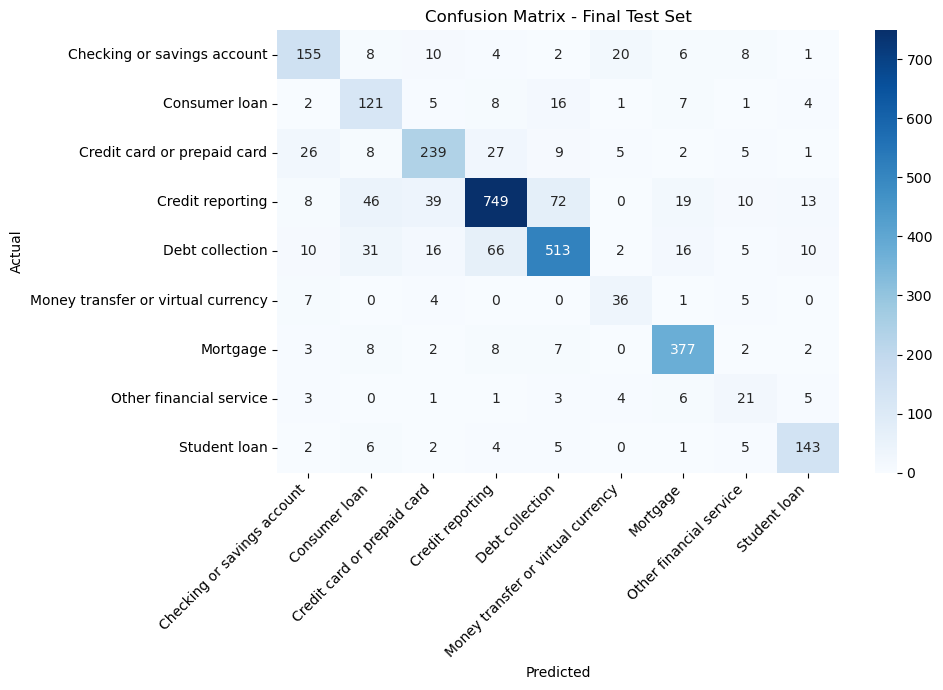

In [16]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred_test, labels=final_clf.classes_)

plt.figure(figsize=(10, 7))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=final_clf.classes_,
    yticklabels=final_clf.classes_
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Final Test Set")
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


The confusion matrix shows the performance of the final TF-IDF + Logistic Regression model on the 3,000 previously unseen test complaints. The diagonal values represent correctly classified complaints, while the off-diagonal values show misclassifications between product categories.

The model performs particularly well for **Mortgage**, with 377 out of 409 complaints classified correctly, and **Credit reporting**, with 749 out of 956 complaints classified correctly. **Student loan** also shows strong performance, with 143 out of 168 complaints correctly classified.

Some confusion occurs between **Credit reporting and Debt collection**. For example, 72 Credit reporting complaints were predicted as Debt collection, while 66 Debt collection complaints were predicted as Credit reporting. This suggests that these categories contain overlapping complaint language that can be difficult to distinguish using TF-IDF features alone.

The **Other financial service** category remains the most difficult class, with only 21 of 44 complaints correctly classified. This is consistent with its relatively small representation in the dataset. **Consumer loan** and **Money transfer or virtual currency** also show lower classification performance compared with the larger categories.

Overall, the confusion matrix supports the evaluation results: the final model performs well on several major product categories but has greater difficulty with smaller classes and categories with similar complaint language.

### Error Analysis

The main errors are concentrated in categories with either limited training examples or overlapping terminology. The confusion between **Credit reporting** and **Debt collection** is particularly important because complaints in both categories can contain similar terms related to debts, accounts, and credit records. The lower performance of **Other financial service** is also likely influenced by its small number of examples. These patterns indicate that improving performance may require additional labelled examples for minority categories and potentially richer features that capture more context than TF-IDF alone.

## 11. Discussion & Conclusion

### Key Findings

- **Model comparison:** TF-IDF + Logistic Regression achieved **79.53% validation accuracy** and **72.78% macro-F1**, compared with **77.00% accuracy** and **70.53% macro-F1** for SBERT + Logistic Regression. Therefore, TF-IDF was selected for the final model.

- **Final performance:** After retraining on the combined training and validation data, the final model achieved **78.47% accuracy** and **71.18% macro-F1** on 3,000 previously unseen test complaints.

- **Strong categories:** The model performed particularly well for **Mortgage (F1 = 0.89)**, **Credit reporting (0.82)**, and **Student loan (0.82)**.

- **Difficult categories:** Performance was lower for **Other financial service (F1 = 0.40)** and **Money transfer or virtual currency (0.60)**. The confusion matrix also showed overlap between **Credit reporting** and **Debt collection**.

### Strengths

- The pipeline provides an **end-to-end NLP solution** from text preprocessing to classification and evaluation.
- TF-IDF + Logistic Regression is relatively **simple, efficient, and suitable for high-dimensional text data**.
- Stratified sampling and `class_weight='balanced'` were used to address class imbalance.
- The model was compared with SBERT using the same validation data before selecting the final approach.

### Limitations

- The model uses a **20,000-record sample** rather than all available complaints with narratives.
- The product categories remain **imbalanced**, and minority categories are more difficult to classify.
- Only the **complaint narrative** was used; additional fields such as issue, sub-product, or company were not included.
- A **random stratified split** was used instead of a time-based split. Therefore, performance on future complaints may differ from the test results.
- SBERT used **pre-trained embeddings with Logistic Regression** rather than transformer fine-tuning, so a fine-tuned transformer model may produce different results.
- Complaint narratives may contain sensitive information, so real-world deployment would require appropriate **privacy and data-governance controls**.

### Recommendations

- Use the model as a **first-stage complaint-routing tool**, rather than fully automated decision-making.
- Route high-confidence predictions automatically and send uncertain cases for **manual review**.
- Monitor complaint volumes and category patterns to identify **changes or emerging trends**.
- Before deployment, evaluate the model on **newer complaint data** and monitor performance over time.
- Consider incorporating additional complaint fields and richer NLP models to improve classification, particularly for minority and overlapping categories.

### Conclusion

This project developed an end-to-end NLP pipeline for classifying consumer financial complaints into product categories. The comparison showed that **TF-IDF + Logistic Regression** was more effective than the tested SBERT approach for this dataset. The final model achieved **78.47% accuracy and 71.18% macro-F1** on unseen test data.

The results show that a relatively simple NLP approach can provide useful support for complaint routing. However, limitations related to class imbalance, overlapping categories, sampling, and generalisation mean that the system should **support human decision-making rather than completely replace it**.

## References

Consumer Financial Protection Bureau (n.d.) *Consumer Complaint Database*. Available at: https://www.consumerfinance.gov/data-research/consumer-complaints/ (Accessed: 15 September 2026).

Kaggle (n.d.) *Consumer Complaint Database*. Available at: https://www.kaggle.com/datasets/selener/consumer-complaint-database (Accessed: 15 September 2026).

Pedregosa, F. et al. (2011) ‘Scikit-learn: Machine Learning in Python’, *Journal of Machine Learning Research*, 12, pp. 2825–2830.

Reimers, N. and Gurevych, I. (2019) ‘Sentence-BERT: Sentence Embeddings using Siamese BERT-Networks’, *Proceedings of the 2019 Conference on Empirical Methods in Natural Language Processing*, pp. 3982–3992.